# Telco Customer Churn Prediction — End-to-End Analysis

**Goal:** identify customers likely to churn and the factors driving churn,
using the IBM/Kaggle Telco Customer Churn dataset (7,043 customers, 21
features). This is an independent portfolio project — not affiliated with
any employer — built to demonstrate a complete data science workflow:
EDA → feature engineering → model comparison → evaluation → business
recommendations.

**Author:** Rasoul Abouassaf

**Dataset:** IBM Telco Customer Churn sample dataset, widely used as a
standard churn-modeling benchmark
(source: https://github.com/IBM/telco-customer-churn-on-icp4d).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Palette: fixed categorical order, validated for adjacent-pair distinguishability
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7", "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
})
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("../data/telco_customer_churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` is typed as text because 11 rows hold a blank string instead
of a number — these turn out to be brand-new customers with `tenure == 0`,
so a blank total charge is consistent with the data (no billing cycle
completed yet), not a data-quality error. We convert it to numeric and fill
those 11 rows with 0.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with missing TotalCharges:", df["TotalCharges"].isna().sum())
print("Their tenure values:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is a unique identifier with no predictive value — drop it
df = df.drop(columns=["customerID"])

Rows with missing TotalCharges: 11
Their tenure values: [0]


## 2. Target distribution

Churn is imbalanced (~26.5% positive class), which we account for later
with `class_weight="balanced"` and by reporting precision/recall/F1 rather
than accuracy alone.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


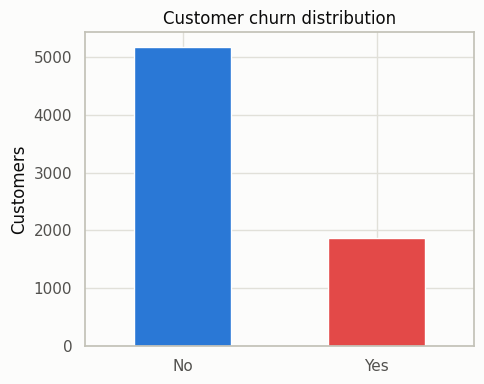

In [5]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].value_counts().reindex(["No", "Yes"]).plot(
    kind="bar", color=[CATEGORICAL[0], CATEGORICAL[7]], ax=ax
)
ax.set_title("Customer churn distribution")
ax.set_xlabel("")
ax.set_ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../screenshots/01_churn_distribution.png", dpi=120)
plt.show()

## 3. Exploratory data analysis

### 3.1 Churn by contract type
Contract type is one of the strongest known churn predictors in this
dataset — worth checking first.

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


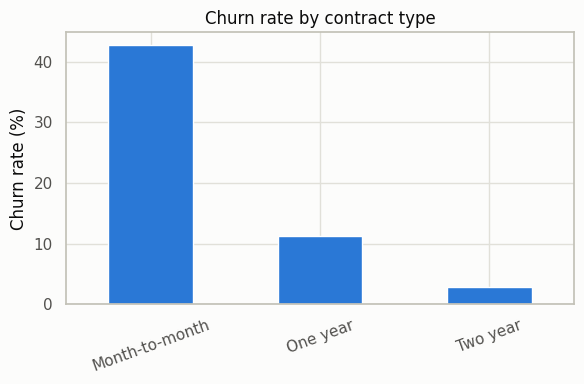

In [6]:
contract_churn = (
    df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
)
print(contract_churn)

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot(kind="bar", color=CATEGORICAL[0], ax=ax)
ax.set_title("Churn rate by contract type")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../screenshots/02_churn_by_contract.png", dpi=120)
plt.show()

### 3.2 Churn by tenure
Newer customers churn far more than long-tenured ones — a classic
"early-lifecycle risk" pattern.

tenure_bucket
0-6 mo      52.937205
7-12 mo     35.886525
13-24 mo    28.710938
25-48 mo    20.388959
49-72 mo     9.513176
Name: Churn, dtype: float64


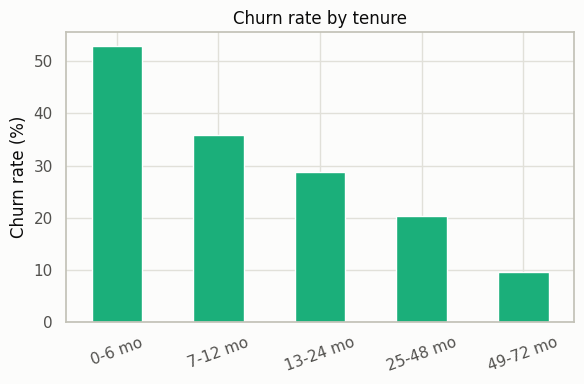

In [7]:
df["tenure_bucket"] = pd.cut(
    df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 mo", "7-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"],
)
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
print(tenure_churn)

fig, ax = plt.subplots(figsize=(6, 4))
tenure_churn.plot(kind="bar", color=CATEGORICAL[2], ax=ax)
ax.set_title("Churn rate by tenure")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../screenshots/03_churn_by_tenure.png", dpi=120)
plt.show()

### 3.3 Monthly charges vs. churn

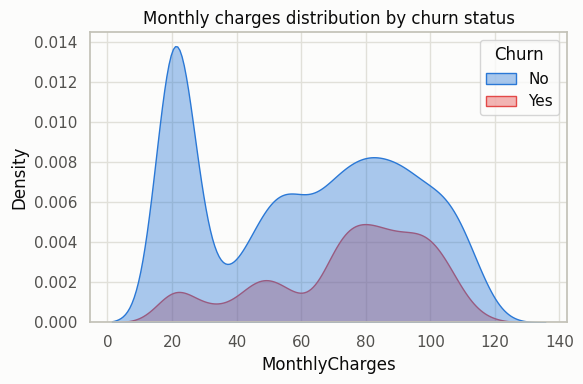

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True,
            palette={"No": CATEGORICAL[0], "Yes": CATEGORICAL[7]}, ax=ax, alpha=0.4)
ax.set_title("Monthly charges distribution by churn status")
plt.tight_layout()
plt.savefig("../screenshots/04_monthlycharges_by_churn.png", dpi=120)
plt.show()

### 3.4 Internet service & add-on services
Customers without security/support add-ons churn more — a plausible
upsell/retention lever.

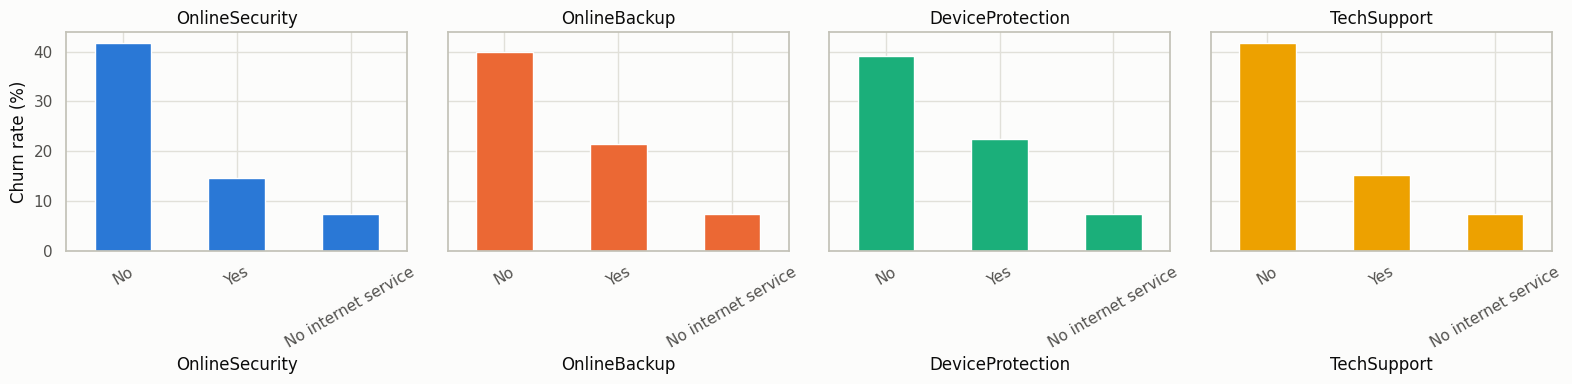

In [9]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
fig, axes = plt.subplots(1, len(service_cols), figsize=(16, 4), sharey=True)
for i, col in enumerate(service_cols):
    rates = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    rates = rates.reindex(["No", "Yes", "No internet service"]).dropna()
    rates.plot(kind="bar", ax=axes[i], color=CATEGORICAL[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Churn rate (%)" if i == 0 else "")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../screenshots/05_addon_services_churn.png", dpi=120)
plt.show()

## 4. Feature engineering & preprocessing

Categorical columns are one-hot encoded and numeric columns standardized,
wired together in a single `ColumnTransformer` so the exact same
transformation is applied consistently at train and inference time.

In [10]:
target = df["Churn"].map({"No": 0, "Yes": 1})
features = df.drop(columns=["Churn", "tenure_bucket"])

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [c for c in features.columns if c not in numeric_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train: (5634, 19), Test: (1409, 19)
Train churn rate: 0.265, Test churn rate: 0.265


## 5. Model comparison

Three models of increasing complexity, all wrapped in the same
preprocessing pipeline for a fair comparison: Logistic Regression
(interpretable baseline), Random Forest, and XGBoost (gradient boosting).
`class_weight="balanced"` / `scale_pos_weight` compensate for the ~26/74
class imbalance so the models aren't just predicting the majority class.

In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision (churn)": precision_score(y_test, y_pred),
        "Recall (churn)": recall_score(y_test, y_pred),
        "F1 (churn)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
print(results_df)

                     Precision (churn)  Recall (churn)  F1 (churn)  ROC-AUC
Model                                                                      
Logistic Regression              0.505           0.783       0.614    0.842
Random Forest                    0.533           0.759       0.626    0.842
XGBoost                          0.526           0.781       0.629    0.839


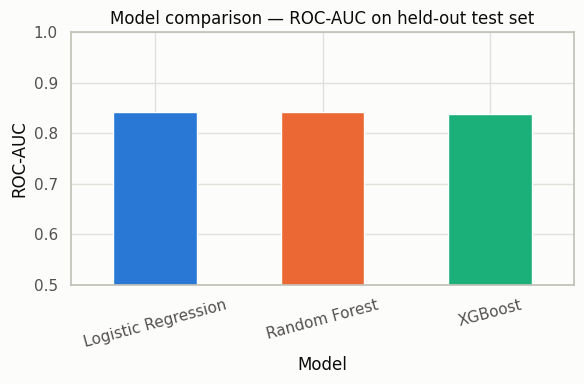

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
results_df["ROC-AUC"].plot(kind="bar", color=CATEGORICAL[:3], ax=ax)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model comparison — ROC-AUC on held-out test set")
ax.set_ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../screenshots/06_model_comparison.png", dpi=120)
plt.show()

## 6. Closer look at the best model

In [13]:
best_name = results_df["ROC-AUC"].idxmax()
best_pipe = fitted_pipelines[best_name]
print(f"Best model by ROC-AUC: {best_name}")

y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

Best model by ROC-AUC: Logistic Regression
              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



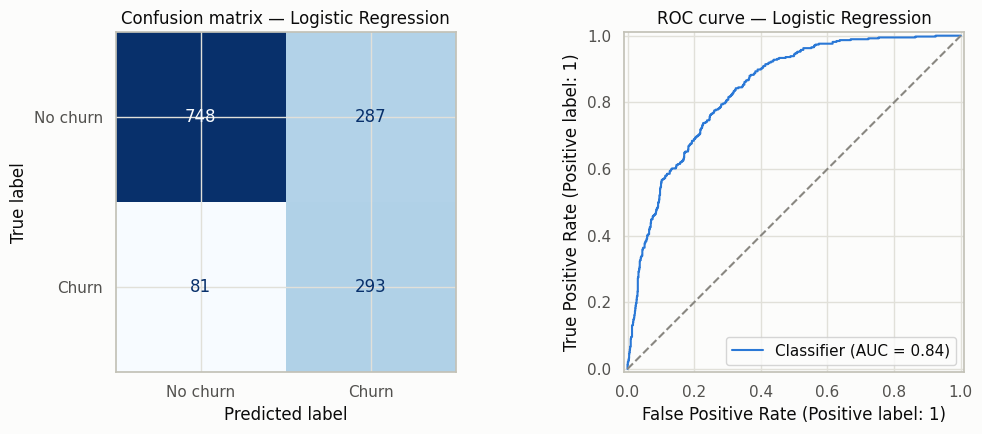

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No churn", "Churn"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title(f"Confusion matrix — {best_name}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=CATEGORICAL[0])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#898781")
axes[1].set_title(f"ROC curve — {best_name}")
plt.tight_layout()
plt.savefig("../screenshots/07_confusion_and_roc.png", dpi=120)
plt.show()

## 7. What drives churn? Feature importance

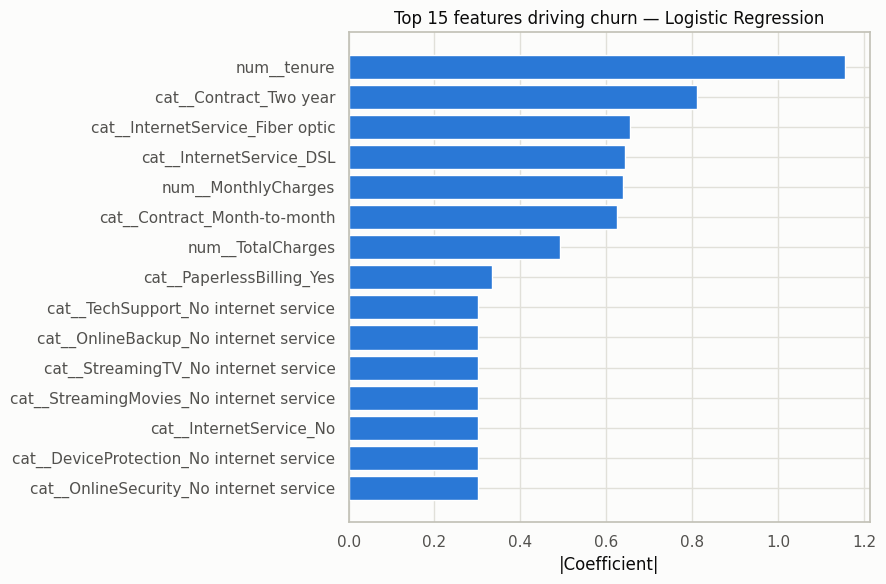

In [15]:
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
best_model = best_pipe.named_steps["model"]

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_label = "Importance"
else:
    # Logistic Regression: use the absolute standardized coefficient as the
    # importance proxy — coefficients are on one-hot/standardized features,
    # so magnitudes are directly comparable.
    importances = np.abs(best_model.coef_[0])
    importance_label = "|Coefficient|"

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=CATEGORICAL[0])
ax.set_title(f"Top 15 features driving churn — {best_name}")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.savefig("../screenshots/08_feature_importance.png", dpi=120)
plt.show()

## 8. Scoring a new customer (inference demo)

A quick example of how the fitted pipeline would be used in production to
score a single new customer record.

In [16]:
sample_customer = X_test.iloc[[0]]
churn_probability = best_pipe.predict_proba(sample_customer)[0, 1]
print(f"Sample customer churn probability: {churn_probability:.1%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[0] == 1 else 'Retained'}")

Sample customer churn probability: 11.8%
Actual outcome: Retained


## 9. Save the trained model

In [17]:
import joblib

joblib.dump(best_pipe, "../models/churn_model.joblib")
print("Saved best pipeline to ../models/churn_model.joblib")

Saved best pipeline to ../models/churn_model.joblib


## 10. Conclusions & recommendations

- **Contract type is the single strongest churn driver**: month-to-month
  customers churn at a far higher rate than one- or two-year contract
  customers. Prioritizing contract-upgrade incentives for month-to-month
  customers is the highest-leverage retention action available.
- **Churn risk is concentrated in the first 6 months of tenure.** A
  structured onboarding/check-in program in that window would target the
  highest-risk segment directly.
- **Customers without OnlineSecurity or TechSupport add-ons churn
  noticeably more** than those with them — bundling a trial of these
  services with new sign-ups is a plausible low-cost retention lever.
- Of the three models compared, **all three landed within 0.003 ROC-AUC of
  each other (0.839–0.842)**, with Logistic Regression marginally ahead
  despite being the simplest model. For this dataset, the extra complexity
  of Random Forest and XGBoost did not buy meaningfully better ranking
  performance — a useful, realistic finding in itself, and a reason to
  prefer the fully-interpretable Logistic Regression model for stakeholder
  communication (it's straightforward to explain which factors raise or
  lower a customer's churn odds and by how much).
- **Next steps** if this were a live production project: threshold tuning
  against the actual cost of a false negative (a missed churner) vs. a
  false positive (an unnecessary retention offer), monthly model
  retraining, and A/B testing the recommended retention actions above.